<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/14_CNN_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNNs)

## Overview

In the previous chapter, we learned how **Multilayer Perceptrons (MLPs)** classify images by first **flattening** each image into a one-dimensional vector.

Although this approach works, it ignores one of the most important properties of images: **their spatial structure**. Neighboring pixels are often related, but flattening destroys these relationships by treating every pixel as an independent feature.

**Convolutional Neural Networks (CNNs)** are designed specifically for image data. Instead of flattening an image immediately, CNNs process small regions of the image at a time, allowing them to automatically learn useful visual features such as **edges, corners, textures, and shapes**.

Because CNNs reuse the same filters across the entire image, they require **far fewer parameters** than fully connected neural networks while achieving much better performance on computer vision tasks.



Today, CNNs are widely used for:

- Image classification
- Object detection
- Face recognition
- Medical image analysis
- Autonomous driving
- Satellite image processing

In this chapter, we will build the fundamental concepts behind CNNs, including **convolutions, feature maps, padding, stride, pooling**, and finally construct one of the first successful convolutional networks, **LeNet**.

---

## Why Do We Need CNNs?

Suppose we want to classify a handwritten digit.

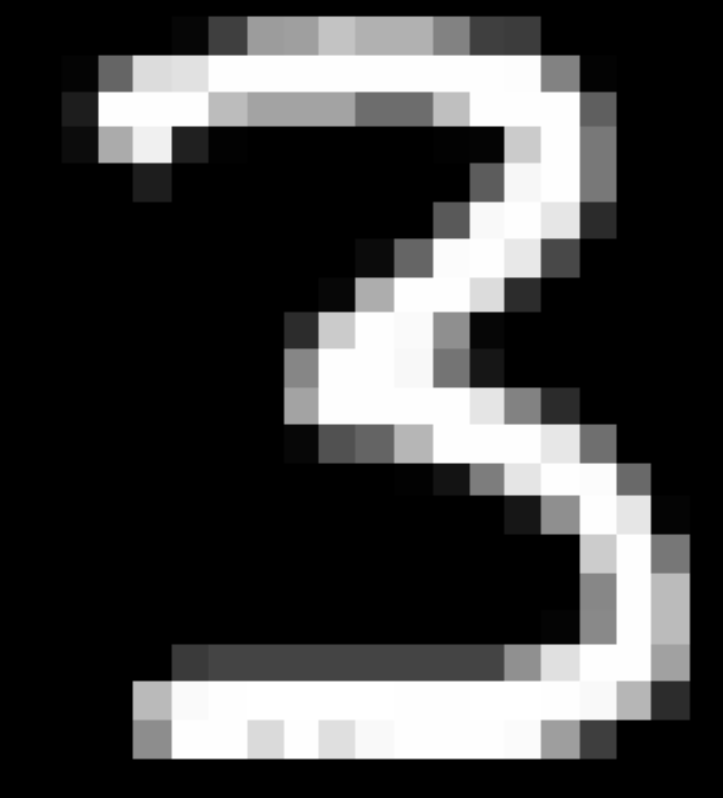

An MLP first converts the image into a long vector of numbers.

```text
Image (28 × 28)

      │
      │ Flatten
      ▼

784-dimensional vector
```

After flattening:

- The original positions of pixels are no longer preserved.
- Neighboring pixels become separated.
- The network has no knowledge of image structure.

As a result, the MLP must learn spatial relationships entirely from the training data, requiring a large number of parameters.

CNNs solve this problem by preserving the two-dimensional structure of the image and learning directly from local neighborhoods of pixels.

---



## Limitations of Fully Connected Networks

Multilayer perceptrons work well with **tabular data**, where rows represent examples and columns represent features.

Images are different because they contain a meaningful **spatial structure**. Nearby pixels are usually related and often form important patterns such as edges, textures, and shapes.

When an image is flattened and passed to an MLP, this spatial organization is no longer explicitly preserved.

---

## The Parameter Problem

Consider a grayscale image with a resolution of \(1000 \times 1000\) pixels.

The image contains:

$$
1000 \times 1000 = 1{,}000{,}000
$$

input features.

If the first hidden layer contains 1000 neurons, the number of weights is:

$$
1{,}000{,}000 \times 1000
=
1{,}000{,}000{,}000
$$

This produces **one billion trainable weights in a single layer**.

Such a model would require:

- Large amounts of memory
- Extensive training data
- Long training times
- Powerful computing hardware

CNNs avoid this problem by exploiting the spatial structure of images and reusing small filters across different image locations.

---




---

## Key Principles Behind CNNs

1. **Translation Equivariance**
   - The same feature can be detected at different image locations.

2. **Local Connectivity**
   - Each neuron initially examines only a small neighborhood of pixels.

3. **Parameter Sharing**
   - The same filter is reused across the entire image.

4. **Hierarchical Feature Learning**
   - Simple patterns are combined into increasingly complex representations.

These principles allow CNNs to process images using far fewer parameters than fully connected networks.

# Invariance

A visual feature should be recognized regardless of where it appears in an image.

For example, a network trained to recognize a cat should still detect it when the cat appears:

- near the center,
- in a corner,
- near the top, or
- near the bottom of the image.

CNNs apply the same detector across different image locations. This allows a learned feature to be recognized wherever it appears.

> **Translation equivariance:** If an object moves within an image, the corresponding feature response moves with it.

Pooling and later processing can make the final prediction less sensitive to the exact location of the feature. This behavior is commonly called **translation invariance**.

---




## Locality

Useful visual patterns are usually formed by nearby pixels.

Examples include:

- An edge formed by neighboring light and dark pixels
- A corner formed within a small image region
- An eye, nose, or mouth represented by a local pattern

CNNs therefore examine small regions of an image rather than connecting every neuron directly to every pixel.

As layers are stacked, these local features are gradually combined into larger and more complex patterns.

---



## Hierarchical Feature Learning

CNNs learn visual features in stages:

```text
Pixels
   ↓
Edges and corners
   ↓
Textures and simple shapes
   ↓
Object parts
   ↓
Complete objects
```

Early layers focus on small, simple patterns, while deeper layers combine them to represent more complex visual concepts.

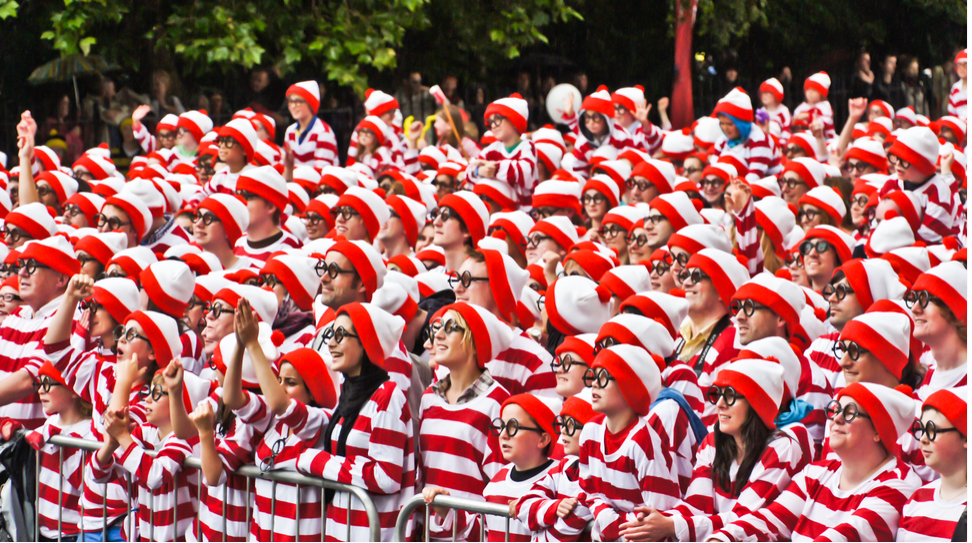

# Convolution

We have seen that CNNs process images using small filters instead of connecting every neuron to every pixel.

The fundamental operation that makes this possible is called **convolution**.

A convolution applies a small matrix, called a **kernel** or **filter**, to an image. The filter slides across the image one region at a time and computes a weighted sum of the pixels beneath it.


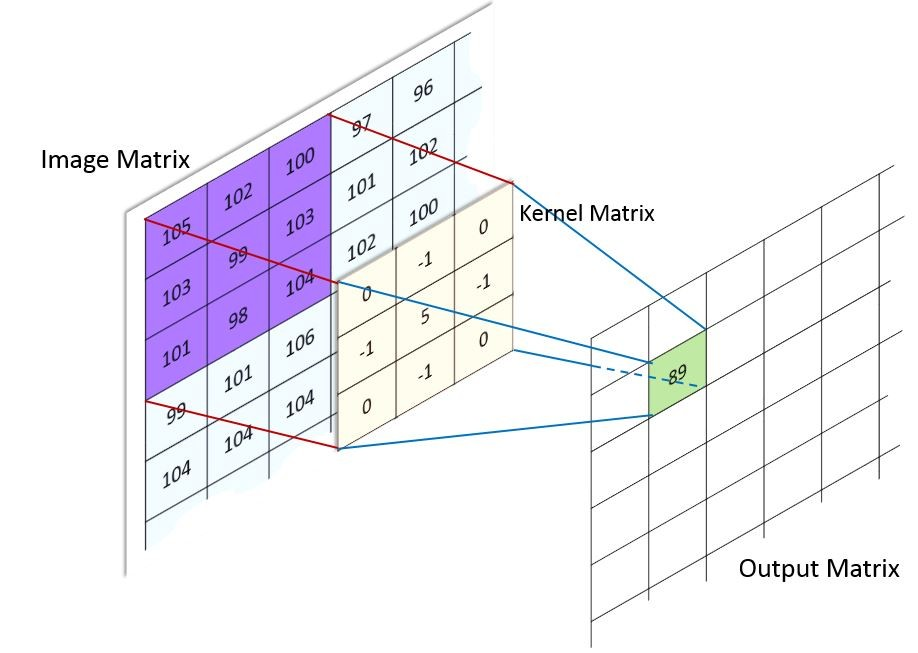


Each position of the filter produces one value in the output feature map. As the filter moves across the image, it detects the presence of specific visual patterns.

For example, different filters may learn to detect:

- Horizontal edges
- Vertical edges
- Corners
- Textures
- Simple shapes

Because the **same filter** is applied at every image location, CNNs require far fewer parameters than fully connected neural networks. This idea is known as **parameter sharing**.

> **Note:** In most deep learning libraries, including TensorFlow and PyTorch, the operation implemented is technically **cross-correlation** rather than the mathematical convolution. In practice, the term **convolution** is used almost universally, so we will follow this convention throughout the course.

---
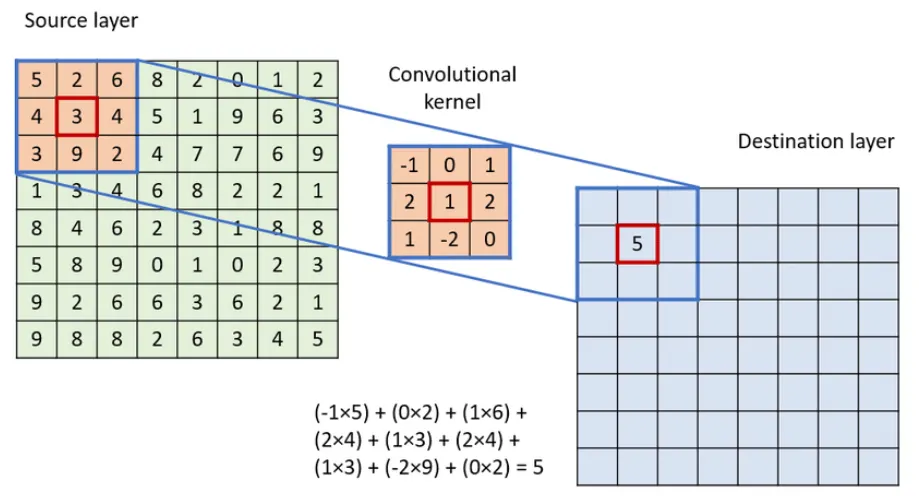

### Key Points

- A convolution uses a small filter to examine local image regions.
- The filter slides across the image.
- Each filter learns to detect a specific visual feature.
- The same filter is reused everywhere in the image (parameter sharing).
- The output of a convolution is called a **feature map**.

# Channels

So far, we have assumed that an image contains only one channel (grayscale). However, most real-world images are **color images**.

A color image is composed of three channels:

- **Red (R)**
- **Green (G)**
- **Blue (B)**

Instead of a two-dimensional matrix, a color image is represented as a three-dimensional tensor:

```
Height × Width × Channels

224 × 224 × 3
```

Each convolution filter must therefore process all input channels simultaneously.

For example, a 3 × 3 filter applied to an RGB image actually has dimensions

```
3 × 3 × 3
```

The filter combines information from the red, green, and blue channels to produce a single output feature map.



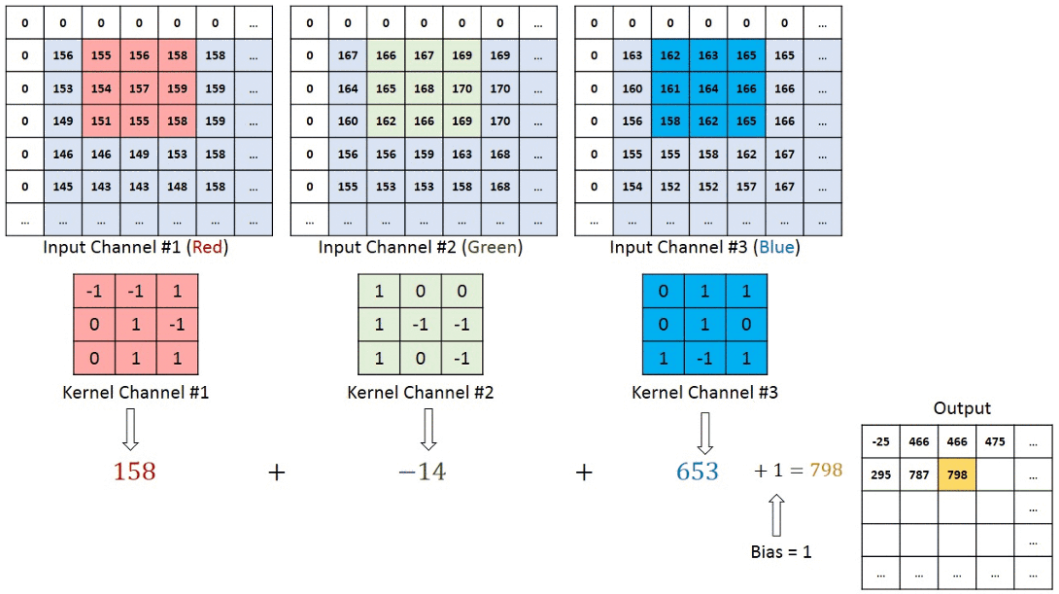


**Note:** A convolution filter applied to an RGB image. Each input channel (Red, Green, and Blue) is convolved with its corresponding kernel. The three results are summed, a bias is added, and the final value becomes one element of the output feature map. Repeating this operation across the image produces the complete feature map.


CNNs typically learn **many filters** in each convolutional layer.

For example,

- Filter 1 may detect vertical edges.
- Filter 2 may detect horizontal edges.
- Filter 3 may detect textures.
- Filter 4 may detect corners.

Each filter produces its own feature map.
```
Input Image (RGB)
        │
        ├── Filter 1 ─► Feature Map 1
        ├── Filter 2 ─► Feature Map 2
        ├── Filter 3 ─► Feature Map 3
        └── Filter 4 ─► Feature Map 4
```

The collection of all feature maps becomes the input to the next convolutional layer.

As more layers are added, the network gradually learns increasingly complex visual features, progressing from edges and textures to object parts and eventually complete objects.

---

### Key Points

- Color images contain three channels (RGB).
- Each convolution filter spans **all input channels**.
- Every filter produces one feature map.
- Multiple filters create multiple output channels.
- Deeper CNN layers learn progressively more complex features.

## Summary

In this section, we introduced the motivation behind convolutional neural networks and the key ideas that make them effective for image processing.

We learned that CNNs:

- Preserve the spatial structure of images.
- Process small local regions instead of connecting every pixel to every neuron.
- Reuse the same filters across the entire image, greatly reducing the number of trainable parameters.
- Learn multiple feature maps, allowing different filters to detect different visual patterns.
- Build increasingly complex representations by stacking convolutional layers.

Now that we understand **why CNNs work**, we are ready to study **how convolution is actually performed** using kernels and sliding windows.